# E-ML - Phishing Email Detection with Machine Learning Methods
### By Colin Harrison, Aidan Huerta, and Drew Levy
---

In [1]:
print("Importing necessary libraries...\n")

import datasets
import re
import requests
import nltk
import sklearn
import torch
import random

import warnings
warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nltk import word_tokenize, FreqDist, pos_tag

from sklearn import linear_model, metrics

from sklearn.feature_extraction.text import *

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, f1_score, recall_score

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.model_selection import RandomizedSearchCV

from scipy.stats import uniform, randint
from sklearn.linear_model import LogisticRegression


from transformers import AutoTokenizer, AutoModel


from typing import Any, Dict, Iterable, List, Optional, Set, Tuple

import gensim
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

from xgboost import XGBClassifier

# Might be necessary
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('universal_tagset', quiet=True)

# Set the Seeds
SEED = 42
random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Set the Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected; training may be slow")
print("\nDone!")

Importing necessary libraries...

Using device: cpu

Done!


In [2]:
# Load and Split Data
data_df = pd.read_csv('Phishing_Email.csv')
train_size = .8
validation_size = .1
test_size = .1

# Uses global Seed for random_state
train_df, temp_df = train_test_split(data_df, train_size = train_size, random_state= SEED)
validation_df, test_df = train_test_split(temp_df, test_size=.5, random_state= SEED)

# Configure Pandas Display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 70)
pd.set_option('display.expand_frame_rep', False)


print("Training Data shape:", train_df.shape)
print("Validation Data shape:", validation_df.shape)
print("Testing Data shape:", test_df.shape)
print()
print("Below is a small sample of what the data we will be using looks like:")

sample_phishing = train_df[train_df['Email Type'] == 'Phishing Email'].sample(n=3, random_state=SEED)
sample_safe = train_df[train_df['Email Type'] == 'Safe Email'].sample(n=3, random_state=SEED)

print(pd.concat([sample_phishing, sample_safe]))

Training Data shape: (14920, 3)
Validation Data shape: (1865, 3)
Testing Data shape: (1865, 3)

Below is a small sample of what the data we will be using looks like:
      Unnamed: 0                                                             Email Text      Email Type
6199        6199  sorry , one more thing cheating adult personals get laid now . rea...  Phishing Email
5658        5658  payment representative dear sir / madam , i am mr . liu peijin , m...  Phishing Email
5466        5466  When Economy goes down, WE go UP !$3000 COMMISSION per Sale for YO...  Phishing Email
7321        7322  fifth annual graduate romanic association at the u . of penn . * *...      Safe Email
3140        3140  december conference preliminary announcement first international w...      Safe Email
3510        3510  re : term project : brian , no problem . vince " brian corbett nel...      Safe Email


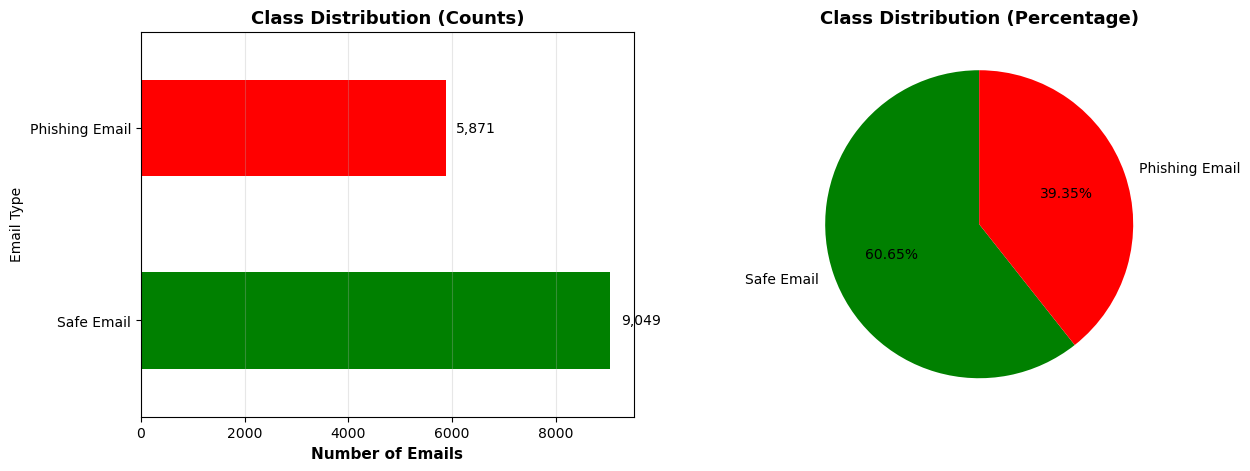

In [3]:
label_cols = ["Email Type"]
counts = train_df[label_cols[0]].value_counts().sort_values(ascending=False)
percentages = (counts / len(train_df)) *100

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

colors = ["green", "red"]
counts.plot(kind='barh', ax=ax1, color=colors)
ax1.set_xlabel('Number of Emails', fontsize=11, fontweight='bold')
ax1.set_title('Class Distribution (Counts)', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, (label, value) in enumerate(counts.items()):
    ax1.text(value + 200, i, f'{value:,}', va='center', fontsize=10)

percentages.plot(kind='pie', ax=ax2, colors=colors, autopct='%1.2f%%', startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')
ax2.set_ylabel('')
plt.show()

## Linear Classification Baselines ##

### Logistic Regression with Bag-of-Words Features ###

In [4]:
train_email_text = train_df["Email Text"].fillna("")
test_email_text = test_df["Email Text"].fillna("")

print("Initializing CountVectorizer (unigrams + bigrams, stopwords removed)...\n")
bow_vectorizer = CountVectorizer(stop_words = 'english', ngram_range=(1,2) )

print("Vectorizing training email text (learning vocabulary)...")
X_train = bow_vectorizer.fit_transform(train_email_text)

print("Vectorizing validation email text using learned vocabulary...\n")
X_test = bow_vectorizer.transform(test_email_text)

print(f"Vocabulary size (number of features): {X_train.shape[1]}")

print("Encoding email labels as binary values (1 = phishing, 0 = safe)\n")
Y_train = (train_df["Email Type"] == "Phishing Email").astype(int)
Y_test = (test_df["Email Type"] == "Phishing Email").astype(int)
print("Done!")

Initializing CountVectorizer (unigrams + bigrams, stopwords removed)...

Vectorizing training email text (learning vocabulary)...
Vectorizing validation email text using learned vocabulary...

Vocabulary size (number of features): 1445686
Encoding email labels as binary values (1 = phishing, 0 = safe)

Done!


In [5]:
print("Training Logistic Regression classifier with Bag-of-Words Features...\n")
bow_lr_classifier = LogisticRegression(penalty="l2",max_iter=3000,random_state = SEED)

bow_lr_classifier.fit(X_train, Y_train)

y_pred = bow_lr_classifier.predict(X_test)

y_proba = bow_lr_classifier.predict_proba(X_test)[:, 1]

print("Evaluating model performance on test data...")

print("\nDetailed Classification Report: Bag-of-Words Features")
print(classification_report(Y_test, y_pred, target_names=["Safe Email", "Phishing Email"], digits=4))

print("Test AUROC:", roc_auc_score(Y_test, y_proba))

Training Logistic Regression classifier with Bag-of-Words Features...

Evaluating model performance on test data...

Detailed Classification Report: Bag-of-Words Features
                precision    recall  f1-score   support

    Safe Email     0.9884    0.9701    0.9792      1139
Phishing Email     0.9545    0.9821    0.9681       726

      accuracy                         0.9748      1865
     macro avg     0.9714    0.9761    0.9736      1865
  weighted avg     0.9752    0.9748    0.9749      1865

Test AUROC: 0.9964627518702065


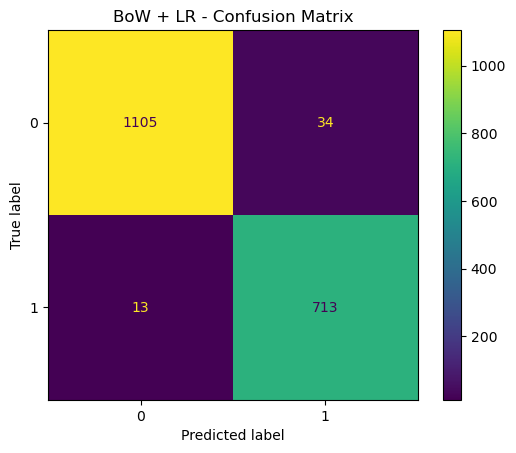

In [6]:
y_pred = bow_lr_classifier.predict(X_test)
c_matrix = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=c_matrix).plot()
plt.title('BoW + LR - Confusion Matrix')
plt.show()

## TF-IDF + Logistic Regression

In [7]:
train_email_text = train_df["Email Text"].fillna("")
test_email_text = test_df["Email Text"].fillna("")

print("Initializing TF-IDF Vectorizer (unigrams + bigrams, stopwords removed)...\n")
tf_idf_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2,          # helps remove noise
    max_df=0.95,       # ignore extremely common terms
    sublinear_tf=True  # 1 + log(tf)
)

print("Vectorizing training email text (learning vocabulary)...")
X_train = tf_idf_vectorizer.fit_transform(train_email_text)

print("Vectorizing TEST email text using learned vocabulary...\n")
X_test = tf_idf_vectorizer.transform(test_email_text)

print(f"Vocabulary size (number of features): {X_train.shape[1]}")

# These remain the same for both feature types # 
print("Encoding email labels as binary values (1 = phishing, 0 = safe)\n")
Y_train = (train_df["Email Type"] == "Phishing Email").astype(int)
Y_test = (test_df["Email Type"] == "Phishing Email").astype(int)
print("Done!")

Initializing TF-IDF Vectorizer (unigrams + bigrams, stopwords removed)...

Vectorizing training email text (learning vocabulary)...
Vectorizing TEST email text using learned vocabulary...

Vocabulary size (number of features): 636676
Encoding email labels as binary values (1 = phishing, 0 = safe)

Done!


In [8]:
print("Training Logistic Regression classifier with TF-IDF Features...\n")
tf_idf_lr_classifier = LogisticRegression(penalty="l2",max_iter=3000,random_state = SEED )

tf_idf_lr_classifier.fit(X_train, Y_train)

y_pred = tf_idf_lr_classifier.predict(X_test)

y_proba = tf_idf_lr_classifier.predict_proba(X_test)[:, 1]

print("Evaluating model performance on TEST data...")

print("\nDetailed Classification Report: TF-IDF Features")
print(classification_report(Y_test, y_pred, target_names=["Safe Email", "Phishing Email"],digits=4))

print("Test AUROC:", roc_auc_score(Y_test, y_proba))

Training Logistic Regression classifier with TF-IDF Features...

Evaluating model performance on TEST data...

Detailed Classification Report: TF-IDF Features
                precision    recall  f1-score   support

    Safe Email     0.9806    0.9754    0.9780      1139
Phishing Email     0.9617    0.9697    0.9657       726

      accuracy                         0.9732      1865
     macro avg     0.9712    0.9726    0.9718      1865
  weighted avg     0.9733    0.9732    0.9732      1865

Test AUROC: 0.9974749490273476


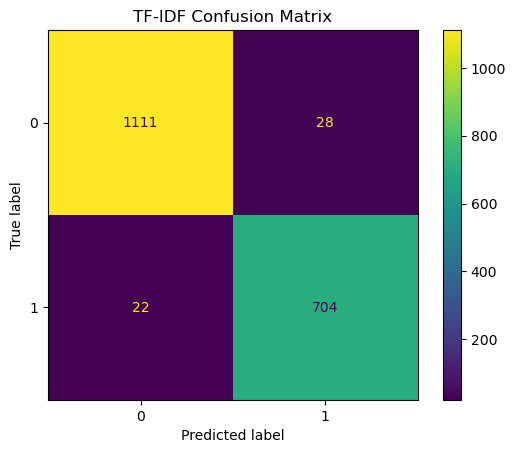

In [9]:
y_pred = tf_idf_lr_classifier.predict(X_test)
c_matrix = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=c_matrix).plot()
plt.title("TF-IDF Confusion Matrix")
plt.show()

### Word2Vec

In [11]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='gensim')

import logging
logging.get_logger("gensim").setLevel(logging.ERROR)

def preprocess_email(text):

    if pd.isna(text):
        return []
    text= text.lower()

    # remove HTML, emails and special characters that might mess up our tokenization
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\\x[0-9a-fA-F]{2}', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    tokens = simple_preprocess(text, deacc=True)

    tokens = [word for word in tokens if not is_junk(word)]

    return tokens

# Follows the vowel to constant ratio to determine if we dealing with actual words
def is_junk(word, threshold=0.3):
    if len(word) <3:
        return False
    vowels = sum(1 for char in word if char in 'aeiou')
    vowel_ratio = vowels / len(word)

    return vowel_ratio < .15 or vowel_ratio > .8
print("Preprocessing text data")
train_df['tokens'] = train_df['Email Text'].apply(preprocess_email)
test_df['tokens'] = test_df['Email Text'].apply(preprocess_email)

print("Training Word2Vec model")
sentences = train_df['tokens'].tolist()

#We can do hyperparameter tuning here later and compare different results
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=10,
    min_count=3,
    workers=3,
    sg=1,
    epochs=30,
    seed=SEED
)

print(f"Word2Vec vocab size: {len(w2v_model.wv)}")

def get_document_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(vectors) >0:
        mean_vec = np.mean(vectors, axis=0)
        max_vec = np.max(vectors, axis=0)
        min_vec = np.min(vectors, axis=0)
        return np.concatenate([mean_vec, max_vec, min_vec])
    else:
        return np.zeros(vector_size*3)

train_df['doc_vector'] = train_df['tokens'].apply(
    lambda x: get_document_vector(x, w2v_model, vector_size=100)
)

test_df['doc_vector'] = test_df['tokens'].apply(
    lambda x: get_document_vector(x, w2v_model, vector_size=100)
)

X_train = np.vstack(train_df['doc_vector'].values)
X_test = np.vstack(test_df['doc_vector'].values)

y_train = (train_df['Email Type'] == 'Phishing Email').astype(int).values
y_test = (test_df['Email Type'] == 'Phishing Email').astype(int).values

print(f"\nFeature matrix shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

Preprocessing text data
Training Word2Vec model


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


KeyboardInterrupt: 